# CS729 Question 2: Comparing Privacy Accountants for DP-SGD

In this notebook, we solve **Question 2** of the assignment.

The objective is to compare four privacy accounting approaches for DP-SGD on **MNIST** using a **feed-forward neural network**:

1. **Advanced Composition Theorem** (manual baseline)
2. **RDP Accountant** (`rdp`)
3. **GDP Accountant** (`gdp`)
4. **PRV Accountant** (`prv`)

We fix a target privacy budget of:

\[
\epsilon = 5
\]

and compare the methods in terms of:

- the **noise multiplier** required to satisfy the same target privacy budget,
- the **privacy spent vs epochs**,
- and the resulting **test accuracy**.

The core idea is simple: different accountants estimate privacy loss differently, even under the same DP-SGD training setup. Hence, some accountants are tighter and allow lower noise for the same target \(\epsilon\), which can lead to better utility.

In [21]:
!pip install opacus -q

In [22]:
import math
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

from opacus import PrivacyEngine
from opacus.accountants.utils import get_noise_multiplier

## Experimental Setup

We follow the same basic setup as Question 1:

- **Dataset:** MNIST
- **Model:** feed-forward neural network
- **Optimizer:** SGD
- **Training algorithm:** DP-SGD
- **Target privacy budget:** \(\epsilon = 5\)
- **Privacy parameter:** \(\delta = 10^{-5}\)

For the Opacus-based accountants (`rdp`, `gdp`, `prv`), we use the official `get_noise_multiplier(...)` helper to compute the noise multiplier needed to reach the target budget.

For **advanced composition**, since Opacus does not provide it directly, we implement a manual baseline using the classical approximate-DP composition theorem together with the standard Gaussian mechanism bound.

This manual advanced-composition baseline should be interpreted as a **classical, conservative reference point**, not as a modern tight accountant.

In [23]:
SEED = 42

BATCH_SIZE = 64
TEST_BATCH_SIZE = 1024
EPOCHS = 10

LR = 0.1
MOMENTUM = 0.0

TARGET_EPSILON = 5.0
DELTA = 1e-5
MAX_GRAD_NORM = 1.0

ACCOUNTANTS = ["advanced", "rdp", "gdp", "prv"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


## Reproducibility

In [24]:
def seed_everything(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(SEED)

## Data Loading

In [25]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

def make_train_loader(seed: int = SEED, shuffle: bool = True):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

def make_test_loader():
    return DataLoader(
        test_dataset,
        batch_size=TEST_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

base_train_loader = make_train_loader()
test_loader = make_test_loader()

N_TRAIN = len(train_dataset)
STEPS_PER_EPOCH = len(base_train_loader)
TOTAL_STEPS = STEPS_PER_EPOCH * EPOCHS
SAMPLE_RATE = BATCH_SIZE / N_TRAIN

print("Training samples:", N_TRAIN)
print("Batches per epoch:", STEPS_PER_EPOCH)
print("Total steps:", TOTAL_STEPS)
print("Sample rate:", SAMPLE_RATE)

Training samples: 60000
Batches per epoch: 938
Total steps: 9380
Sample rate: 0.0010666666666666667


## Model

We use a simple feed-forward neural network, as required in the assignment.

In [26]:
class FeedForwardNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

def build_model():
    return FeedForwardNet().to(DEVICE)

def build_optimizer(model):
    return optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

## Train / eval helpers

In [27]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    iteration_losses = []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        loss_val = loss.item()
        running_loss += loss_val
        iteration_losses.append(loss_val)

    epoch_loss = running_loss / len(loader)
    return iteration_losses, epoch_loss

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    avg_loss = total_loss / total
    acc = 100.0 * correct / total
    return avg_loss, acc

## Manual Advanced Composition Baseline

Opacus supports the accountants `rdp`, `gdp`, and `prv`, but **does not directly provide advanced composition as an accountant option**. So we implement a classical baseline manually.

We use the following idea:

1. Treat each DP-SGD step as a Gaussian mechanism with noise multiplier \(\sigma\).
2. Convert that step into a per-step \((\epsilon_0, \delta_0)\)-DP guarantee using the standard Gaussian upper bound.
3. Compose over \(T\) steps using the **advanced composition theorem**.

This is intentionally a **conservative baseline**:
- it does **not** exploit modern tight privacy accounting,
- and it is mainly here to contrast classical composition with tighter modern accountants.

In [28]:
def gaussian_eps_per_step(sigma: float, delta_step: float) -> float:
    """
    Classical Gaussian mechanism upper bound:
        eps <= sqrt(2 * log(1.25/delta_step)) / sigma
    Valid as a conservative approximate-DP bound.
    """
    if sigma <= 0:
        raise ValueError("sigma must be positive")
    return math.sqrt(2.0 * math.log(1.25 / delta_step)) / sigma

def advanced_composition_epsilon(
    sigma: float,
    steps: int,
    delta_total: float,
    q: float  # <--- ADDED SAMPLING RATE
) -> float:
    if steps <= 0:
        raise ValueError("steps must be positive")
        
    delta_prime = delta_total / 2.0
    
    # 1. Delta allocated per step
    delta_step = delta_total / (2.0 * steps)
    
    # 2. Because of subsampling, the BASE delta needed is actually delta_step / q
    base_delta = delta_step / q
    
    # 3. Calculate raw Gaussian epsilon (without subsampling)
    raw_eps0 = gaussian_eps_per_step(sigma, base_delta)
    
    try:
        # 4. APPLY PRIVACY AMPLIFICATION BY SUBSAMPLING
        eps_sub = math.log(1.0 + q * math.expm1(raw_eps0))
        
        # 5. NOW compose the subsampled epsilon
        eps_total = (
            math.sqrt(2.0 * steps * math.log(1.0 / delta_prime)) * eps_sub 
            + steps * eps_sub * (math.exp(eps_sub) - 1.0)
        )
        return eps_total
        
    except OverflowError:
        # If sigma is too small, raw_eps0 gets huge and math.exp() crashes.
        # Returning infinity tells the binary search to increase sigma.
        return float('inf')

def solve_sigma_for_advanced_composition(
    target_epsilon: float,
    steps: int,
    delta_total: float,
    q: float, # <--- ADDED SAMPLING RATE
    sigma_low: float = 0.01,
    sigma_high: float = 1000.0,
    tol: float = 1e-4,
    max_iter: int = 200,
):
    def f(sig):
        return advanced_composition_epsilon(sig, steps, delta_total, q) # Pass q here


    # ensure upper bound is feasible
    while f(sigma_high) > target_epsilon:
        sigma_high *= 2.0
        if sigma_high > 1e6:
            raise RuntimeError("Could not find a large enough sigma for advanced composition.")

    for _ in range(max_iter):
        mid = 0.5 * (sigma_low + sigma_high)
        eps_mid = f(mid)

        if abs(eps_mid - target_epsilon) < tol:
            return mid

        if eps_mid > target_epsilon:
            sigma_low = mid
        else:
            sigma_high = mid

    return sigma_high

## Noise Calibration

For each accountant, we now compute the noise multiplier required to satisfy the same target privacy budget:

\[
(\epsilon, \delta) = (5, 10^{-5})
\]

- For `rdp`, `gdp`, and `prv`, we use Opacus's official `get_noise_multiplier(...)`.
- For `advanced`, we use the manual binary search above.

This is one of the cleanest ways to compare accountants fairly: same data, same model, same optimizer, same target privacy budget — only the accounting method changes.

In [29]:
noise_multipliers = {}

for acc in ACCOUNTANTS:
    if acc == "advanced":
        sigma = solve_sigma_for_advanced_composition(
            target_epsilon=TARGET_EPSILON,
            steps=TOTAL_STEPS,
            delta_total=DELTA,
            q=SAMPLE_RATE # <--- PASS SAMPLE RATE HERE
        )
    else:
        sigma = get_noise_multiplier(
            target_epsilon=TARGET_EPSILON,
            target_delta=DELTA,
            sample_rate=SAMPLE_RATE,
            epochs=EPOCHS,
            accountant=acc,
            epsilon_tolerance=0.01,
        )
    noise_multipliers[acc] = sigma

noise_df = pd.DataFrame({
    "accountant": list(noise_multipliers.keys()),
    "noise_multiplier": list(noise_multipliers.values())
}).sort_values("noise_multiplier")

noise_df

/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/accountants/gdp.py:23: UserWarning: GDP accounting is experimental and can underestimate privacy expenditure.Proceed with caution. More details: https://arxiv.org/pdf/2106.02848.pdf
  warnings.warn(


,accountant,noise_multiplier
2,gdp,0.457611
3,prv,0.509186
1,rdp,0.538330
0,advanced,2.425573


## Training routine

We train one DP-SGD model per accountant.

For the Opacus accountants:
- we use `PrivacyEngine(accountant=...)`
- we call `make_private(...)` with the calibrated noise multiplier

For the advanced-composition baseline:
- training still uses Opacus for clipping + noise addition,
- but privacy spending is **reported manually** using the classical theorem instead of an Opacus accountant.

This lets us compare the *privacy accounting method* while keeping the DP-SGD training mechanism itself consistent.

## Training helpers for Q2

In [30]:
@dataclass
class RunMetrics:
    accountant: str
    noise_multiplier: float
    iteration_losses: list
    epoch_losses: list
    epsilons: list
    test_losses: list
    test_accuracies: list
    final_test_loss: float
    final_accuracy: float
    final_epsilon: float

def advanced_epsilon_after_epochs(sigma: float, current_epoch: int) -> float:
    steps_so_far = current_epoch * STEPS_PER_EPOCH
    return advanced_composition_epsilon(
        sigma=sigma,
        steps=steps_so_far,
        delta_total=DELTA,
        q=SAMPLE_RATE  # <--- JUST ADD THIS LINE
    )

def run_dp_experiment(accountant_name: str, sigma: float, seed: int = SEED):
    seed_everything(seed)

    model = build_model()
    optimizer = build_optimizer(model)
    train_loader = make_train_loader(seed=seed, shuffle=True)
    test_loader = make_test_loader()

    if accountant_name == "advanced":
        # Use Opacus for DP training mechanics, but report epsilon manually
        privacy_engine = PrivacyEngine(accountant="rdp")
        model, optimizer, private_loader = privacy_engine.make_private(
            module=model,
            optimizer=optimizer,
            data_loader=train_loader,
            noise_multiplier=sigma,
            max_grad_norm=MAX_GRAD_NORM,
        )
        epsilon_fn = lambda epoch: advanced_epsilon_after_epochs(sigma, epoch)
    else:
        privacy_engine = PrivacyEngine(accountant=accountant_name)
        model, optimizer, private_loader = privacy_engine.make_private(
            module=model,
            optimizer=optimizer,
            data_loader=train_loader,
            noise_multiplier=sigma,
            max_grad_norm=MAX_GRAD_NORM,
        )
        epsilon_fn = lambda epoch: privacy_engine.get_epsilon(delta=DELTA)

    metrics = {
        "accountant": accountant_name,
        "noise_multiplier": sigma,
        "iteration_losses": [],
        "epoch_losses": [],
        "epsilons": [],
        "test_losses": [],
        "test_accuracies": [],
    }

    for epoch in range(1, EPOCHS + 1):
        iter_losses, epoch_loss = train_one_epoch(model, private_loader, optimizer)
        test_loss, test_acc = evaluate(model, test_loader)

        eps_spent = epsilon_fn(epoch)

        metrics["iteration_losses"].extend(iter_losses)
        metrics["epoch_losses"].append(epoch_loss)
        metrics["epsilons"].append(eps_spent)
        metrics["test_losses"].append(test_loss)
        metrics["test_accuracies"].append(test_acc)

        print(
            f"[{accountant_name.upper()}] Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss: {epoch_loss:.4f} | "
            f"Epsilon Spent: {eps_spent:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.2f}%"
        )

    return RunMetrics(
        accountant=metrics["accountant"],
        noise_multiplier=metrics["noise_multiplier"],
        iteration_losses=metrics["iteration_losses"],
        epoch_losses=metrics["epoch_losses"],
        epsilons=metrics["epsilons"],
        test_losses=metrics["test_losses"],
        test_accuracies=metrics["test_accuracies"],
        final_test_loss=metrics["test_losses"][-1],
        final_accuracy=metrics["test_accuracies"][-1],
        final_epsilon=metrics["epsilons"][-1],
    )

## Running all accountant experiments

In [31]:
results = {}

for acc in ACCOUNTANTS:
    print("=" * 80)
    print(f"Running experiment for accountant: {acc}")
    print(f"Noise multiplier: {noise_multipliers[acc]:.6f}")
    results[acc] = run_dp_experiment(acc, noise_multipliers[acc])

print("All Q2 experiments completed.")

Running experiment for accountant: advanced
Noise multiplier: 2.425573


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


[ADVANCED] Epoch 01/10 | Train Loss: 1.0522 | Epsilon Spent: 1.1448 | Test Loss: 1.1127 | Test Acc: 77.80%
[ADVANCED] Epoch 02/10 | Train Loss: 1.6716 | Epsilon Spent: 1.7644 | Test Loss: 2.3542 | Test Acc: 73.22%
[ADVANCED] Epoch 03/10 | Train Loss: 2.7544 | Epsilon Spent: 2.2801 | Test Loss: 2.9833 | Test Acc: 74.95%
[ADVANCED] Epoch 04/10 | Train Loss: 3.8926 | Epsilon Spent: 2.7406 | Test Loss: 4.4561 | Test Acc: 73.80%
[ADVANCED] Epoch 05/10 | Train Loss: 5.0277 | Epsilon Spent: 3.1653 | Test Loss: 5.1660 | Test Acc: 75.05%
[ADVANCED] Epoch 06/10 | Train Loss: 6.3327 | Epsilon Spent: 3.5644 | Test Loss: 6.9159 | Test Acc: 73.73%
[ADVANCED] Epoch 07/10 | Train Loss: 8.3008 | Epsilon Spent: 3.9439 | Test Loss: 8.6452 | Test Acc: 73.14%
[ADVANCED] Epoch 08/10 | Train Loss: 9.4655 | Epsilon Spent: 4.3080 | Test Loss: 9.2410 | Test Acc: 74.14%
[ADVANCED] Epoch 09/10 | Train Loss: 10.9314 | Epsilon Spent: 4.6593 | Test Loss: 11.2847 | Test Acc: 71.64%
[ADVANCED] Epoch 10/10 | Train Loss

/usr/local/lib/python3.12/dist-packages/opacus/accountants/gdp.py:23: UserWarning: GDP accounting is experimental and can underestimate privacy expenditure.Proceed with caution. More details: https://arxiv.org/pdf/2106.02848.pdf
  warnings.warn(


[GDP] Epoch 01/10 | Train Loss: 0.7257 | Epsilon Spent: 1.3584 | Test Loss: 0.4309 | Test Acc: 88.23%
[GDP] Epoch 02/10 | Train Loss: 0.4504 | Epsilon Spent: 1.9960 | Test Loss: 0.4445 | Test Acc: 89.79%
[GDP] Epoch 03/10 | Train Loss: 0.4641 | Epsilon Spent: 2.5054 | Test Loss: 0.4482 | Test Acc: 90.75%
[GDP] Epoch 04/10 | Train Loss: 0.4674 | Epsilon Spent: 2.9475 | Test Loss: 0.4338 | Test Acc: 91.03%
[GDP] Epoch 05/10 | Train Loss: 0.4526 | Epsilon Spent: 3.3463 | Test Loss: 0.4392 | Test Acc: 91.33%
[GDP] Epoch 06/10 | Train Loss: 0.4564 | Epsilon Spent: 3.7141 | Test Loss: 0.4301 | Test Acc: 91.73%
[GDP] Epoch 07/10 | Train Loss: 0.4457 | Epsilon Spent: 4.0583 | Test Loss: 0.4230 | Test Acc: 91.98%
[GDP] Epoch 08/10 | Train Loss: 0.4384 | Epsilon Spent: 4.3837 | Test Loss: 0.4102 | Test Acc: 92.27%
[GDP] Epoch 09/10 | Train Loss: 0.4154 | Epsilon Spent: 4.6938 | Test Loss: 0.4021 | Test Acc: 92.43%
[GDP] Epoch 10/10 | Train Loss: 0.4361 | Epsilon Spent: 4.9908 | Test Loss: 0.4006

## Summary Table

We now summarize the main quantities of interest:

- accountant used,
- calibrated noise multiplier,
- final epsilon spent,
- final test loss,
- final test accuracy.

In [32]:
summary_rows = []
for acc, res in results.items():
    summary_rows.append({
        "accountant": acc,
        "noise_multiplier": res.noise_multiplier,
        "final_epsilon": res.final_epsilon,
        "final_test_loss": res.final_test_loss,
        "final_test_accuracy": res.final_accuracy,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("noise_multiplier")
summary_df

,accountant,noise_multiplier,final_epsilon,final_test_loss,final_test_accuracy
2,gdp,0.457611,4.990844,0.400555,92.83
3,prv,0.509186,4.994139,0.422767,92.64
1,rdp,0.538330,4.990624,0.437519,92.50
0,advanced,2.425573,5.000001,12.498954,73.50


## Plot 1: Epsilon Spent vs Epochs

This plot shows how each accounting method accumulates privacy loss over training epochs.

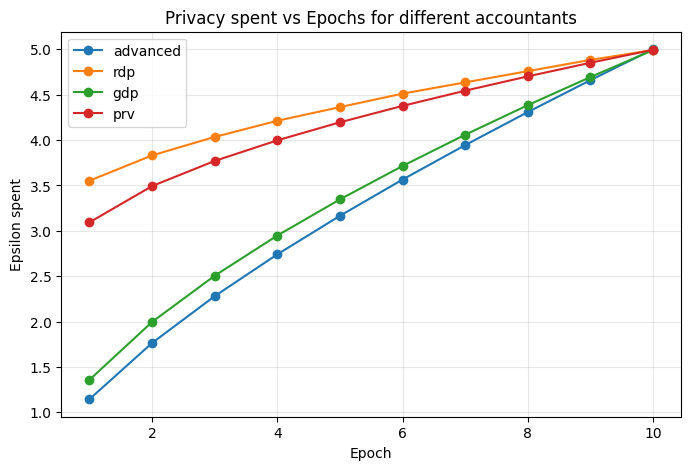

In [33]:
epochs_axis = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
for acc, res in results.items():
    plt.plot(epochs_axis, res.epsilons, marker="o", label=acc)

plt.xlabel("Epoch")
plt.ylabel("Epsilon spent")
plt.title("Privacy spent vs Epochs for different accountants")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Plot 2: Iteration vs Training Loss

This plot compares the optimization behavior under the different accountant-calibrated noise levels.

Since the accountant changes the calibrated noise multiplier, it can also indirectly affect convergence.

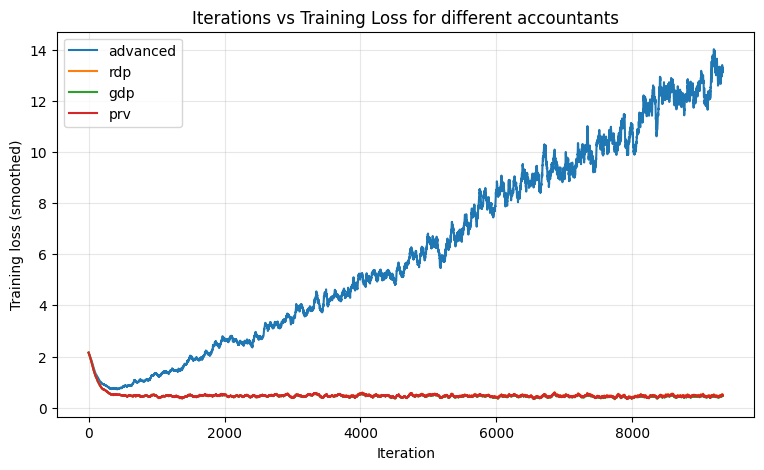

In [34]:
def moving_average(x, window=50):
    if len(x) < window:
        return np.array(x)
    return np.convolve(x, np.ones(window) / window, mode="valid")

plt.figure(figsize=(9, 5))
for acc, res in results.items():
    smoothed = moving_average(res.iteration_losses, window=50)
    plt.plot(smoothed, label=acc)

plt.xlabel("Iteration")
plt.ylabel("Training loss (smoothed)")
plt.title("Iterations vs Training Loss for different accountants")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Plot 3: Required Noise Multiplier

This plot directly compares how much noise each accounting method requires to satisfy the same target privacy budget \((\epsilon=5, \delta=10^{-5})\).

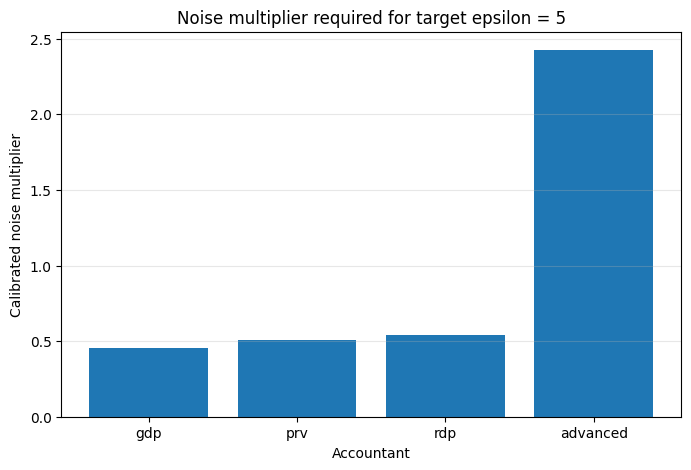

In [35]:
plot_df = summary_df.sort_values("noise_multiplier")

plt.figure(figsize=(8, 5))
plt.bar(plot_df["accountant"], plot_df["noise_multiplier"])
plt.xlabel("Accountant")
plt.ylabel("Calibrated noise multiplier")
plt.title("Noise multiplier required for target epsilon = 5")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## Plot 4: Accountant vs Final Test Accuracy

A tighter accountant may require less noise for the same privacy target, which can improve model utility.

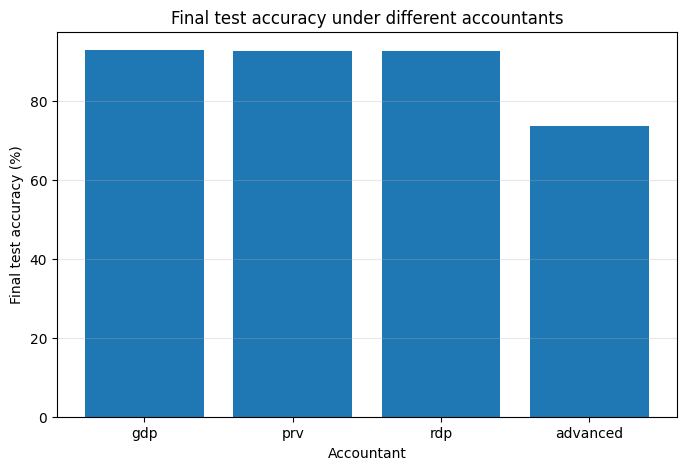

In [36]:
plot_df = summary_df.sort_values("final_test_accuracy", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["accountant"], plot_df["final_test_accuracy"])
plt.xlabel("Accountant")
plt.ylabel("Final test accuracy (%)")
plt.title("Final test accuracy under different accountants")
plt.grid(True, axis="y", alpha=0.3)
plt.show()